In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import random
from scipy.stats import loguniform

# For plotting contours
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

import os

In [2]:
samples = loguniform.rvs(1e-4, 1e-1, size=1000)
print(samples.min(), samples.max(), np.median(samples))

0.00010141428811349731 0.09934387925157526 0.002747360101127933


In [3]:
from src.utils import _isotope_to_element, _isotope_label, _combine_elements
from src.plot import plot_yields
from src.load_data import load_ishigaki, load_hw2002, load_ishigaki_selected
from params import filter_elements, f_star_by_f_dil
from src.salvadori_funcs import salvadori_Zism, salvadori_abundance_ratio, salvadori_H_ratio, salvadori_combined_abundratio,salvadori_combined_abundratio_WrtH
from src.salvadori_funcs import salvadori_yields as salvadori_yields_convert
from src.formulas import abundance_ratio


In [4]:
ishigaki18_yields = load_ishigaki()
hw_yields = load_hw2002()
ishigaki18_selected_yields = load_ishigaki_selected() # NOTE: already summed isotopes

In [5]:
# ishigaki18_selected_yields = [entry for entry in ishigaki18_selected_yields if entry["params"]["mass"] in [25, 40]]
# ishigaki18_selected_yields[0]

In [6]:
hw_yields = hw_yields[1:]

# for entry in hw_yields:
#     entry['yields'] = _combine_elements(entry['yields'])

In [7]:
salvadori_yields = salvadori_yields_convert(hw_yields)

for entry in salvadori_yields:
    entry['yields'] = _combine_elements(entry['yields'])

print("Salvadori Yields:")
print(salvadori_yields[0])

print("HW2002 Yields:")
print(hw_yields[0])

Salvadori Yields:
{'label': 'M=150', 'params': {'mass': 150.0, 'mass_he': 70.0}, 'yields': {'H': 1.9300000000003488e-05, 'He': 0.01034, 'Li': 1.0361333333333333e-24, 'Be': 8.420000000000001e-28, 'B': 5.1800098266666667e-17, 'C': 0.030286669458666666, 'N': 3.826666666666667e-07, 'O': 0.30540001319133336, 'F': 9.38e-11, 'Ne': 0.0269272358, 'Na': 2.0913333333333332e-05, 'Mg': 0.02015212, 'Al': 0.00011793333333333334, 'Si': 0.053319786666666674, 'S': 0.016256180074400002, 'Cl': 9.832666666666666e-06, 'Ar': 0.0020704333337864004, 'K': 8.552232466666666e-06, 'Ca': 0.0012533801161334025, 'Sc': 1.668e-08, 'Ti': 9.088013604200001e-07, 'V': 1.1566799866666668e-07, 'Cr': 7.589459666666667e-06, 'Mn': 4.679333333333334e-06, 'Fe': 0.00024366807206666663, 'Co': 2.45e-08, 'Ni': 8.994419677362128e-06, 'Cu': 2.618796e-14, 'Zn': 1.1233895198000001e-13, 'Ga': 4.254e-18, 'Ge': 1.5215990666666667e-17, 'As': 8.506666666666666e-19, 'Se': 1.7208000000000003e-17, 'Br': 4.214666666666666e-18, 'Kr': 8.87386666666

In [8]:
pisn_yields = hw_yields
# sn_yields = ishigaki18_selected_yields
sn_yields = ishigaki18_yields
sn_yields = [entry for entry in sn_yields if entry["params"]["lfej"] >= 0.0]

for elem in filter_elements:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    X_Fe = []
    Fe_H = []
    for i in range(500):
        pisn_entry = random.choice(pisn_yields)
        sn_entry = random.choice(sn_yields)

        f_pisn = 0.9
        f_ratio = 1e-1

        pisn_details = {
            "mass": pisn_entry["params"]["mass"],
        }
        sn_details = {
            "mass": sn_entry["params"]["mass"],
            "lfej": sn_entry["params"]["lfej"],
            "energy": sn_entry["params"]["energy"],
            "elem_value": sn_entry["yields"].get(elem, 0.0),
            "Fe_value": sn_entry["yields"].get("Fe", 0.0),
        }

        combined_ratio = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_entry, sn_entry, f_pisn=f_pisn)
        combined_ratio_wrtH = salvadori_combined_abundratio_WrtH("Fe","Fe", pisn_entry, sn_entry, f_pisn=f_pisn, f_ratio=f_ratio)

        if combined_ratio < -3 or combined_ratio_wrtH < -3:
        # if sn_entry["yields"].get(elem, 0.0) < 1e-6:
            
            print("Very low ratio detected")
            print("Elem", elem,"\n", "PISN", pisn_details, "\n", "SN", sn_details, "\n", "Combined Ratio", combined_ratio, "\n", "Combined Ratio w.r.t H", combined_ratio_wrtH)
            print("-------------------------------")
            continue # do not add to the list if the ratio is very low, but print details for debugging

        X_Fe.append(combined_ratio)
        Fe_H.append(combined_ratio_wrtH)

    def plot_density_with_marginals(feh_vals, xfe_vals, elem, f_pisn, save_path=None):
        feh_vals = np.array(feh_vals)
        xfe_vals = np.array(xfe_vals)

        mask = np.isfinite(feh_vals) & np.isfinite(xfe_vals)
        feh_vals, xfe_vals = feh_vals[mask], xfe_vals[mask]

        xy = np.vstack([feh_vals, xfe_vals])
        kde = gaussian_kde(xy)

        xmin, xmax = feh_vals.min(), feh_vals.max()
        ymin, ymax = xfe_vals.min(), xfe_vals.max()
        xpad = 0.05 * (xmax - xmin)
        ypad = 0.05 * (ymax - ymin)

        Xg, Yg = np.mgrid[xmin-xpad:xmax+xpad:200j, ymin-ypad:ymax+ypad:200j]
        positions = np.vstack([Xg.ravel(), Yg.ravel()])
        Z = np.reshape(kde(positions).T, Xg.shape)

        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                wspace=0.05, hspace=0.05)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

        cs = ax_main.contourf(Xg, Yg, Z, levels=20, cmap='inferno')
        ax_main.set_xlabel("[Fe/H]")
        ax_main.set_ylabel(f"[{elem}/Fe]")

        ax_top.hist(feh_vals, bins=40, density=True, color='gray')
        ax_top.tick_params(labelbottom=False, labelleft=False)
        ax_top.set_ylabel("P(x)")

        ax_right.hist(xfe_vals, bins=40, density=True, orientation='horizontal', color='gray')
        ax_right.tick_params(labelbottom=False, labelleft=False)
        ax_right.set_xlabel("P(y)")

        ax_top.set_title(f"f_pisn = {f_pisn:.2f}")

        if save_path:
            fig.savefig(save_path, dpi=300)
        plt.close(fig)

    plot_density_with_marginals(Fe_H, X_Fe, elem, f_pisn,
                                save_path=f"plots/abundance_scatter_contour/{elem}_contour.png")
        
    # X_Fe = [x for x in X_Fe if x > -5]
    # Fe_H = [Fe_H[i] for i in range(len(X_Fe)) if X_Fe[i] > -5]
    plt.scatter(Fe_H, X_Fe, alpha=0.5, color='black')
    plt.xlabel("[Fe/H]")
    plt.ylabel("[" + elem + "/Fe]")
    plt.title("f_pisn = " + str(f_pisn) + ", f_ratio = " + str(f_ratio))
    # plt.show()
    f_ratio_str = f"{f_ratio:.0e}".replace("e-0", "e-").replace("e+0", "e+")
    # plt.savefig("plots/f_pisn_" + str(int(f_pisn*100)) + "_f_ratio_" + f_ratio_str + "/" + elem + "_scatter.png", dpi=300)
    plt.savefig(f"plots/abundance_scatter/{elem}_scatter.png", dpi=300)
    plt.clf()
        

Salvadori C/Fe ratio: -0.14539034716871002
Yields: PISN C: 0.0206600017935, PISN Fe: 0.01543085003234, SN C: 0.010717750080369999, SN Fe: 0.010085925351525001
Yields: PISN Z: 0.46764505671461415, SN Z: 0.2886727869533169, beta: 0.11111111111111108
Salvadori Fe/H ratio: -0.006827883784138011
Yields: PISN Fe: 0.01543085003234, SN Fe: 0.010085925351525001
Yields: PISN Z: 0.46764505671461415, SN Z: 0.2886727869533169, beta: 0.11111111111111108
Salvadori C/Fe ratio: -0.8318041166117127
Yields: PISN C: 0.016278261564347828, PISN Fe: 0.0630517391496174, SN C: 0.01066480277748, SN Fe: 0.029919112131324
Yields: PISN Z: 0.470831789892321, SN Z: 0.18786638963438076, beta: 0.11111111111111108
Salvadori Fe/H ratio: 0.6100724507367941
Yields: PISN Fe: 0.0630517391496174, SN Fe: 0.029919112131324
Yields: PISN Z: 0.470831789892321, SN Z: 0.18786638963438076, beta: 0.11111111111111108
Salvadori C/Fe ratio: -1.2180552555961381
Yields: PISN C: 0.013892308223461538, PISN Fe: 0.12445576923968077, SN C: 0.0

<Figure size 1920x1440 with 0 Axes>

In [9]:
Fe_H_pisn = salvadori_abundance_ratio("Fe", "H", salvadori_yields[0])
print("Fe/H for PISN", Fe_H_pisn)

Fe_H_pisn_ratio = salvadori_H_ratio("Fe",1e-4,salvadori_yields[0])
print("Fe/H ratio for PISN", Fe_H_pisn_ratio)

Fe/H for PISN 5.601241318110119
Fe/H ratio for PISN -4.856725136046596


(0.0001, [(150.0, np.float64(-8.856725136046597)), (160.0, np.float64(-8.278625035320285)), (170.0, np.float64(-8.240453680182455)), (180.0, np.float64(-7.836633631275194)), (190.0, np.float64(-7.3834317402750225)), (200.0, np.float64(-7.055133912656408)), (210.0, np.float64(-6.789386976901709)), (220.0, np.float64(-6.596279977861436)), (230.0, np.float64(-6.443826692990355)), (240.0, np.float64(-6.336753387791778)), (250.0, np.float64(-6.2422973117049425)), (260.0, np.float64(-6.148508729709838)), (270.0, np.float64(-6.067819788590438))])
(0.001, [(150.0, np.float64(-6.856725136046596)), (160.0, np.float64(-6.278625035320284)), (170.0, np.float64(-6.240453680182454)), (180.0, np.float64(-5.836633631275194)), (190.0, np.float64(-5.3834317402750225)), (200.0, np.float64(-5.055133912656408)), (210.0, np.float64(-4.789386976901709)), (220.0, np.float64(-4.596279977861437)), (230.0, np.float64(-4.443826692990356)), (240.0, np.float64(-4.336753387791778)), (250.0, np.float64(-4.242297311704

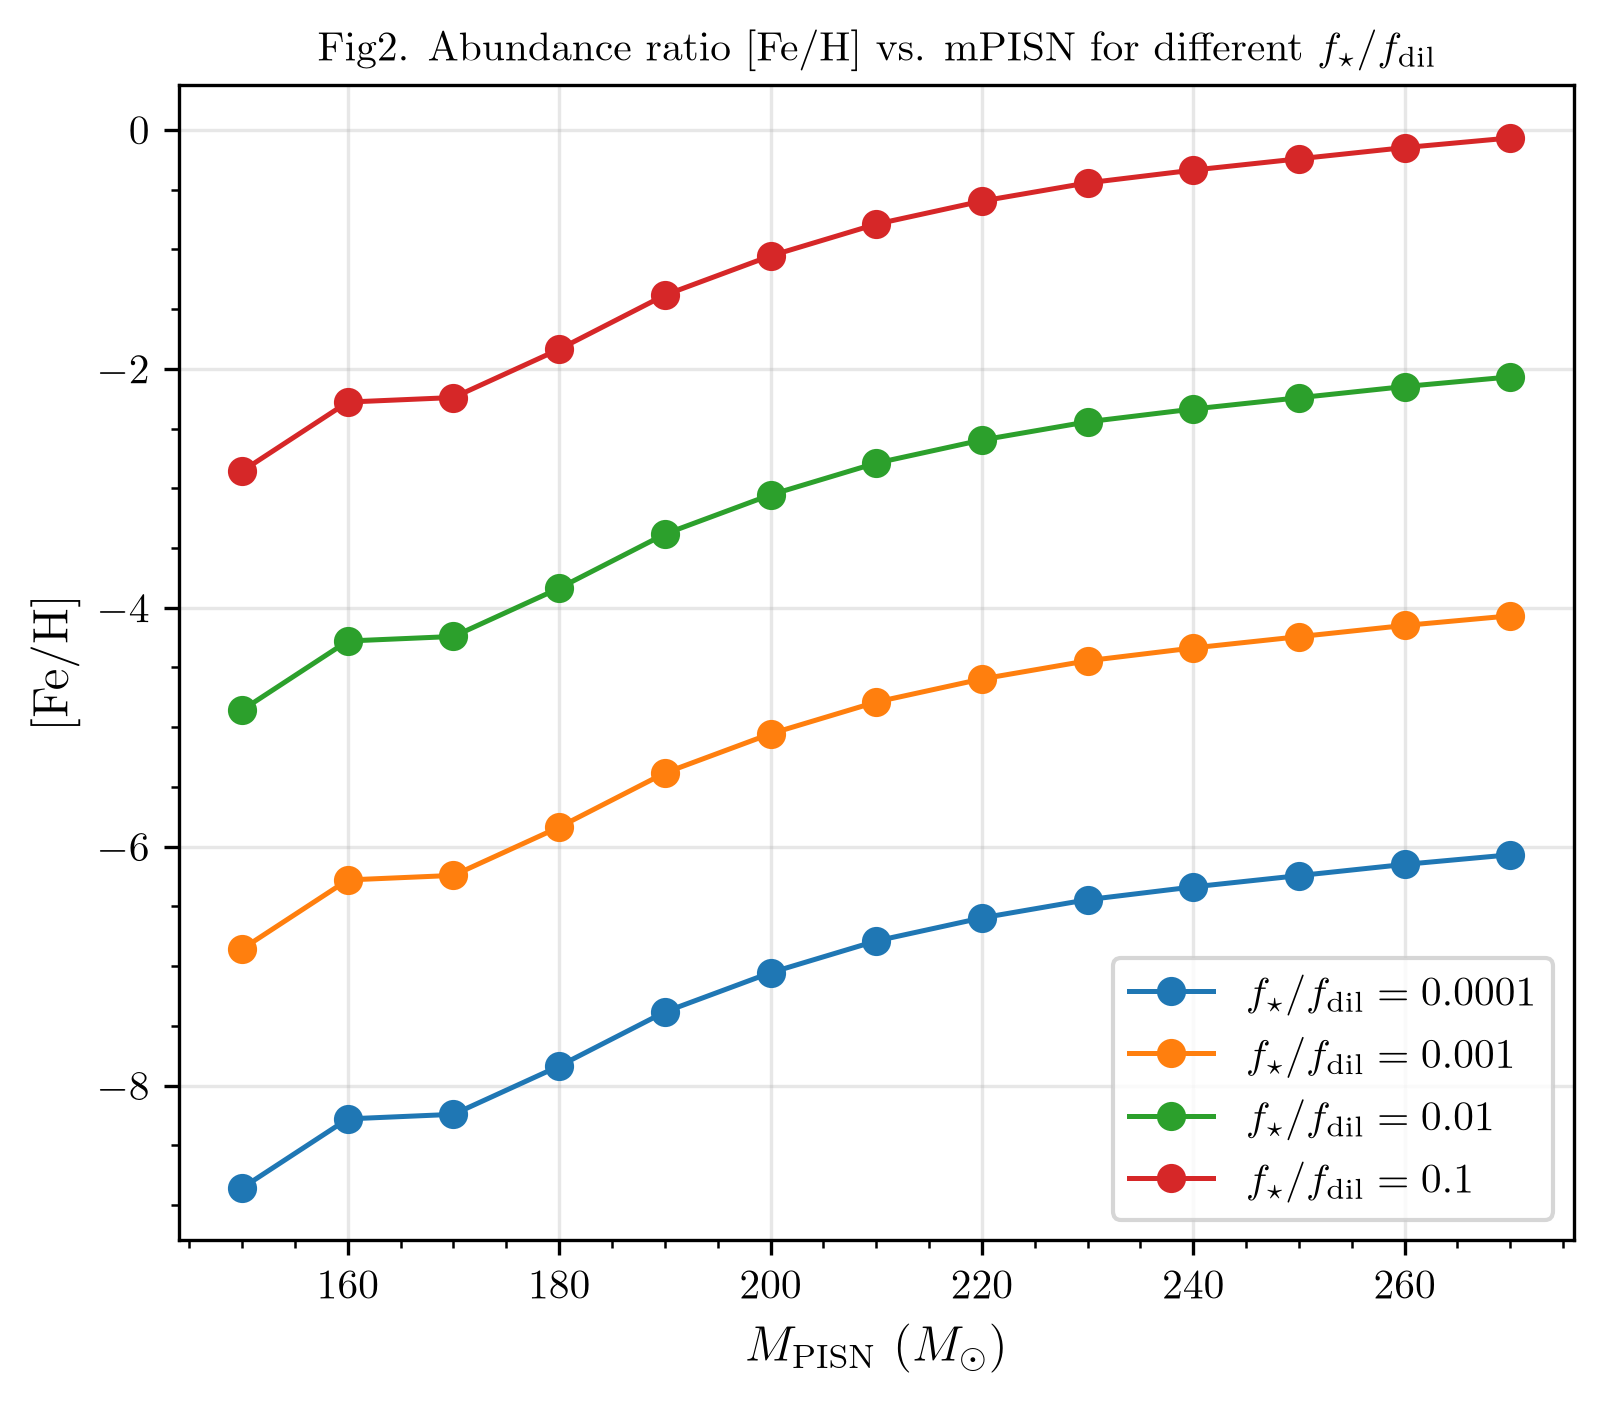

In [10]:
f_star_by_f_dil = [1e-4, 1e-3, 1e-2, 1e-1]

Zism = {}
for f in f_star_by_f_dil:
    Zism[f] = salvadori_Zism(f, salvadori_yields)

fig2_values = []
for f in Zism:
    f_ratio = f
    yield_data = Zism[f]

    Fe_H_to_mPISN = []
    for y in yield_data:
        mass = y['params']['mass']
        Fe = y['yields']['Fe']
        H = y['yields']['H']

        Fe_H = salvadori_H_ratio('Fe', f_ratio, y)

        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values.append((f_ratio, Fe_H_to_mPISN))

print(fig2_values[0])
print(fig2_values[1])

fig, ax = plt.subplots(figsize=(6, 5))

for f_ratio, Fe_H_to_mPISN in fig2_values:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="o", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$")

ax.set_xlabel(r"$M_\mathrm{PISN}\ (M_\odot)$")
ax.set_ylabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.minorticks_on()
plt.title(r"Fig2. Abundance ratio $[\mathrm{Fe}/\mathrm{H}]$ vs. mPISN for different $f_\star/f_\mathrm{dil}$", fontsize=10)
plt.show()


In [11]:
# ishigaki_yields = [
#     e for e in ishigaki18_yields if
#     # e["params"]["lfej"] == 0.0
#     # and
#     e["params"]["mass"] == 25
# ] 

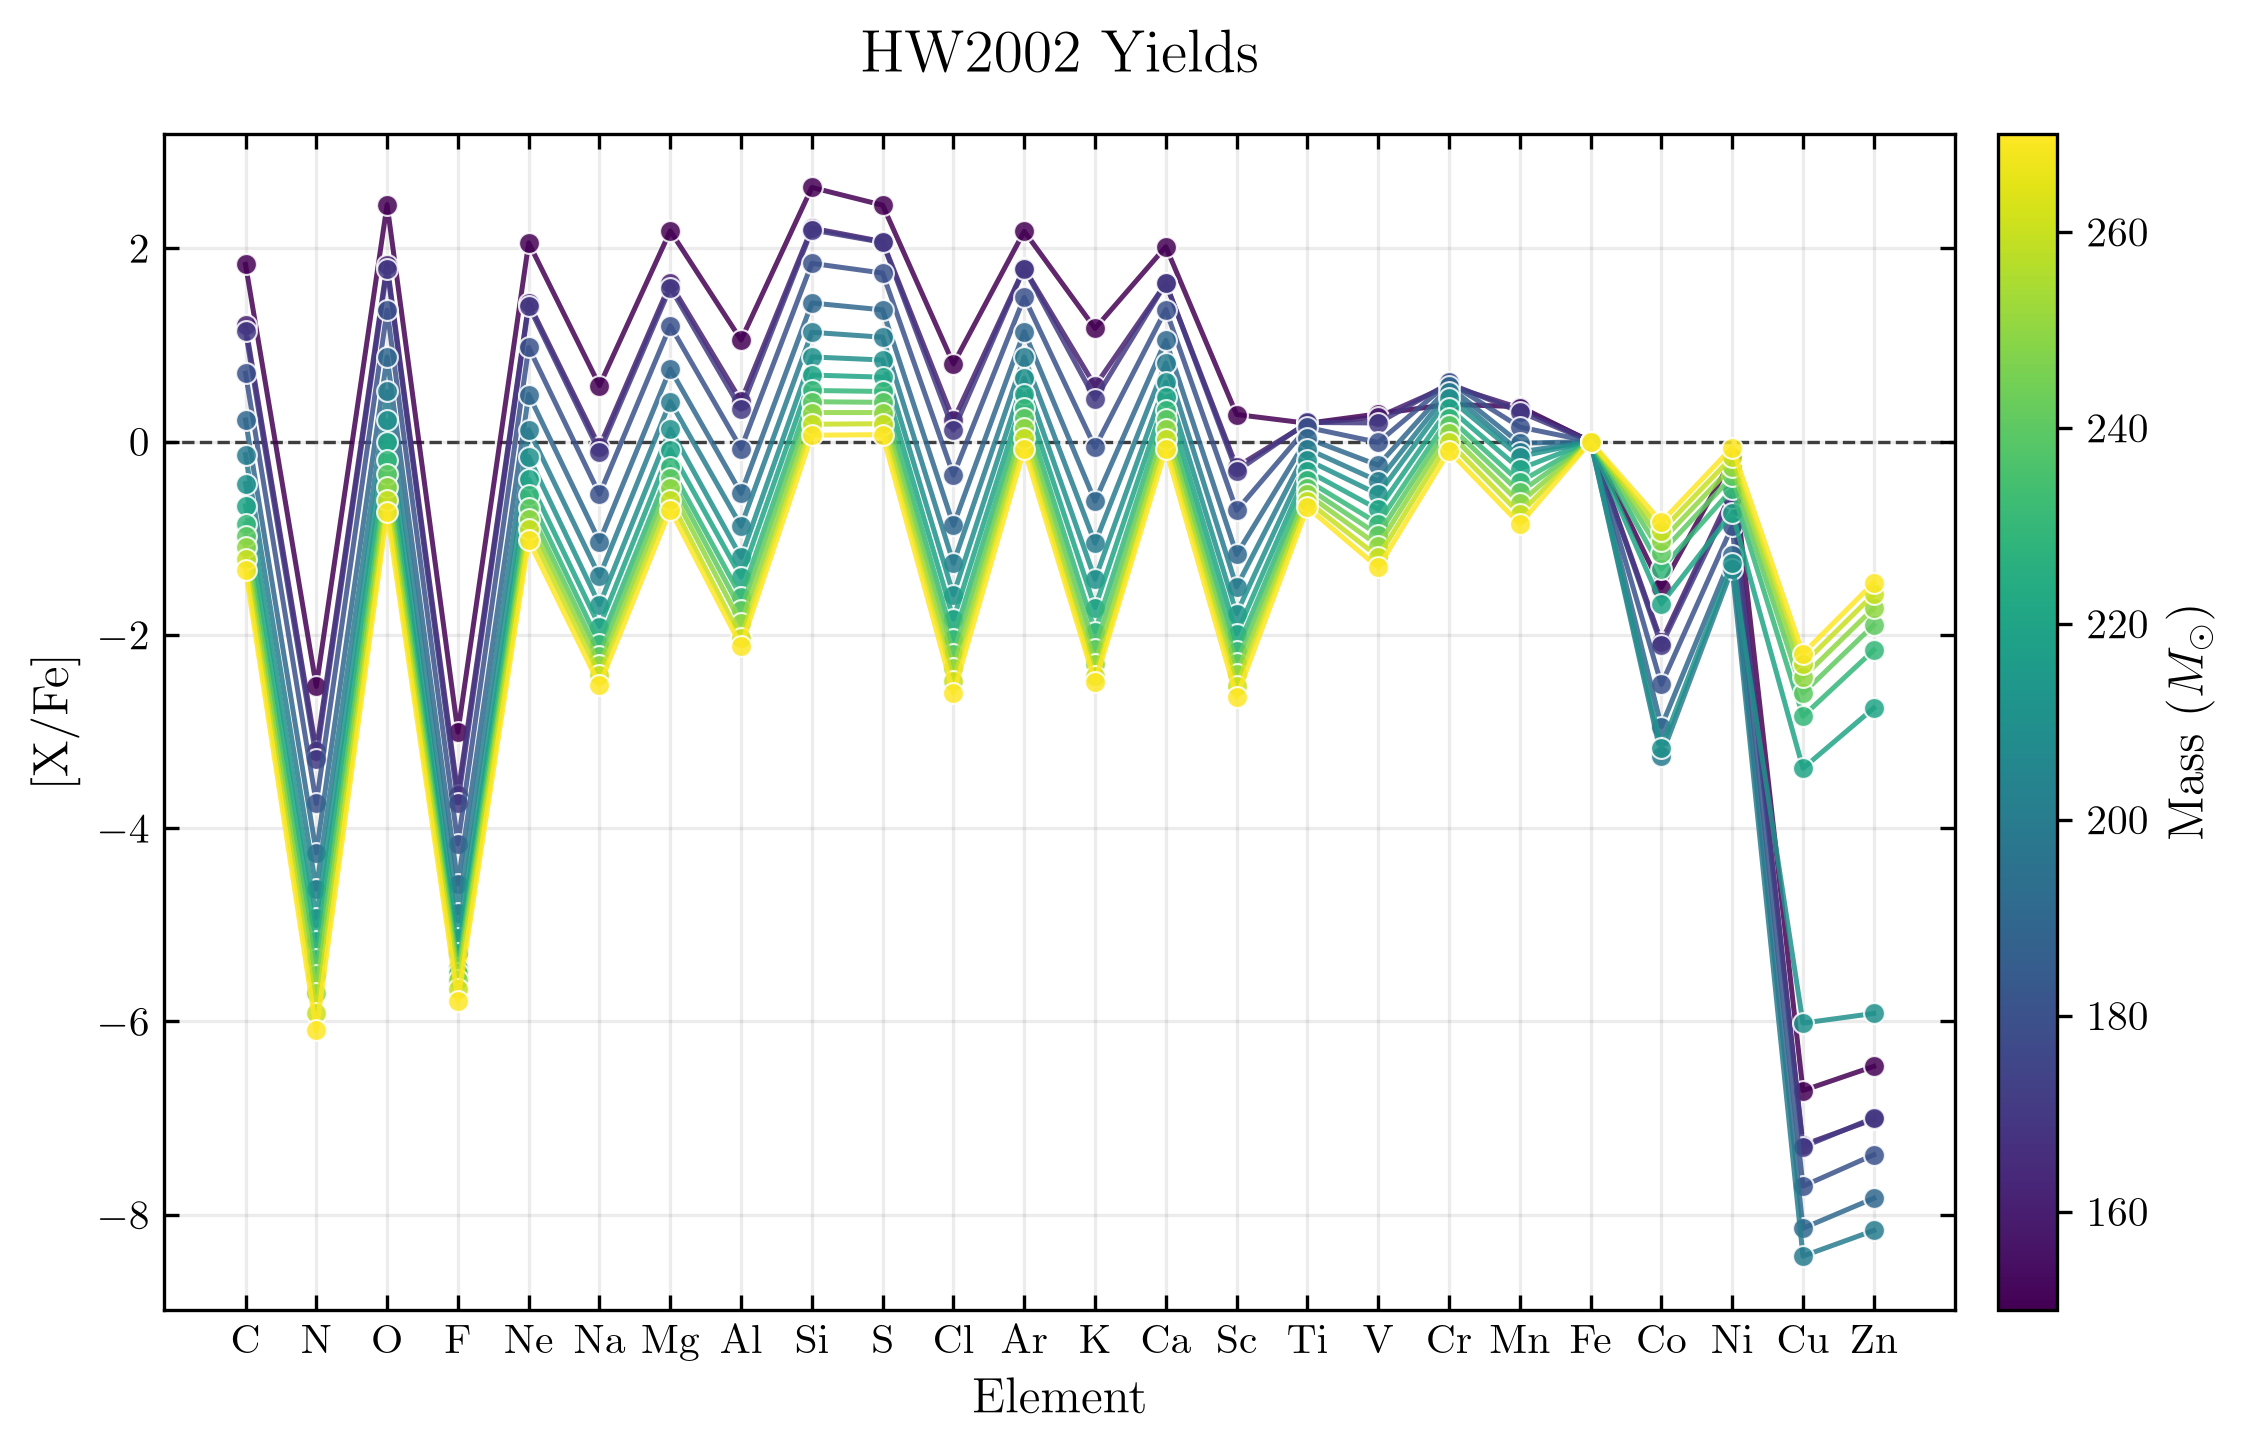

In [12]:
plot_yields(hw_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

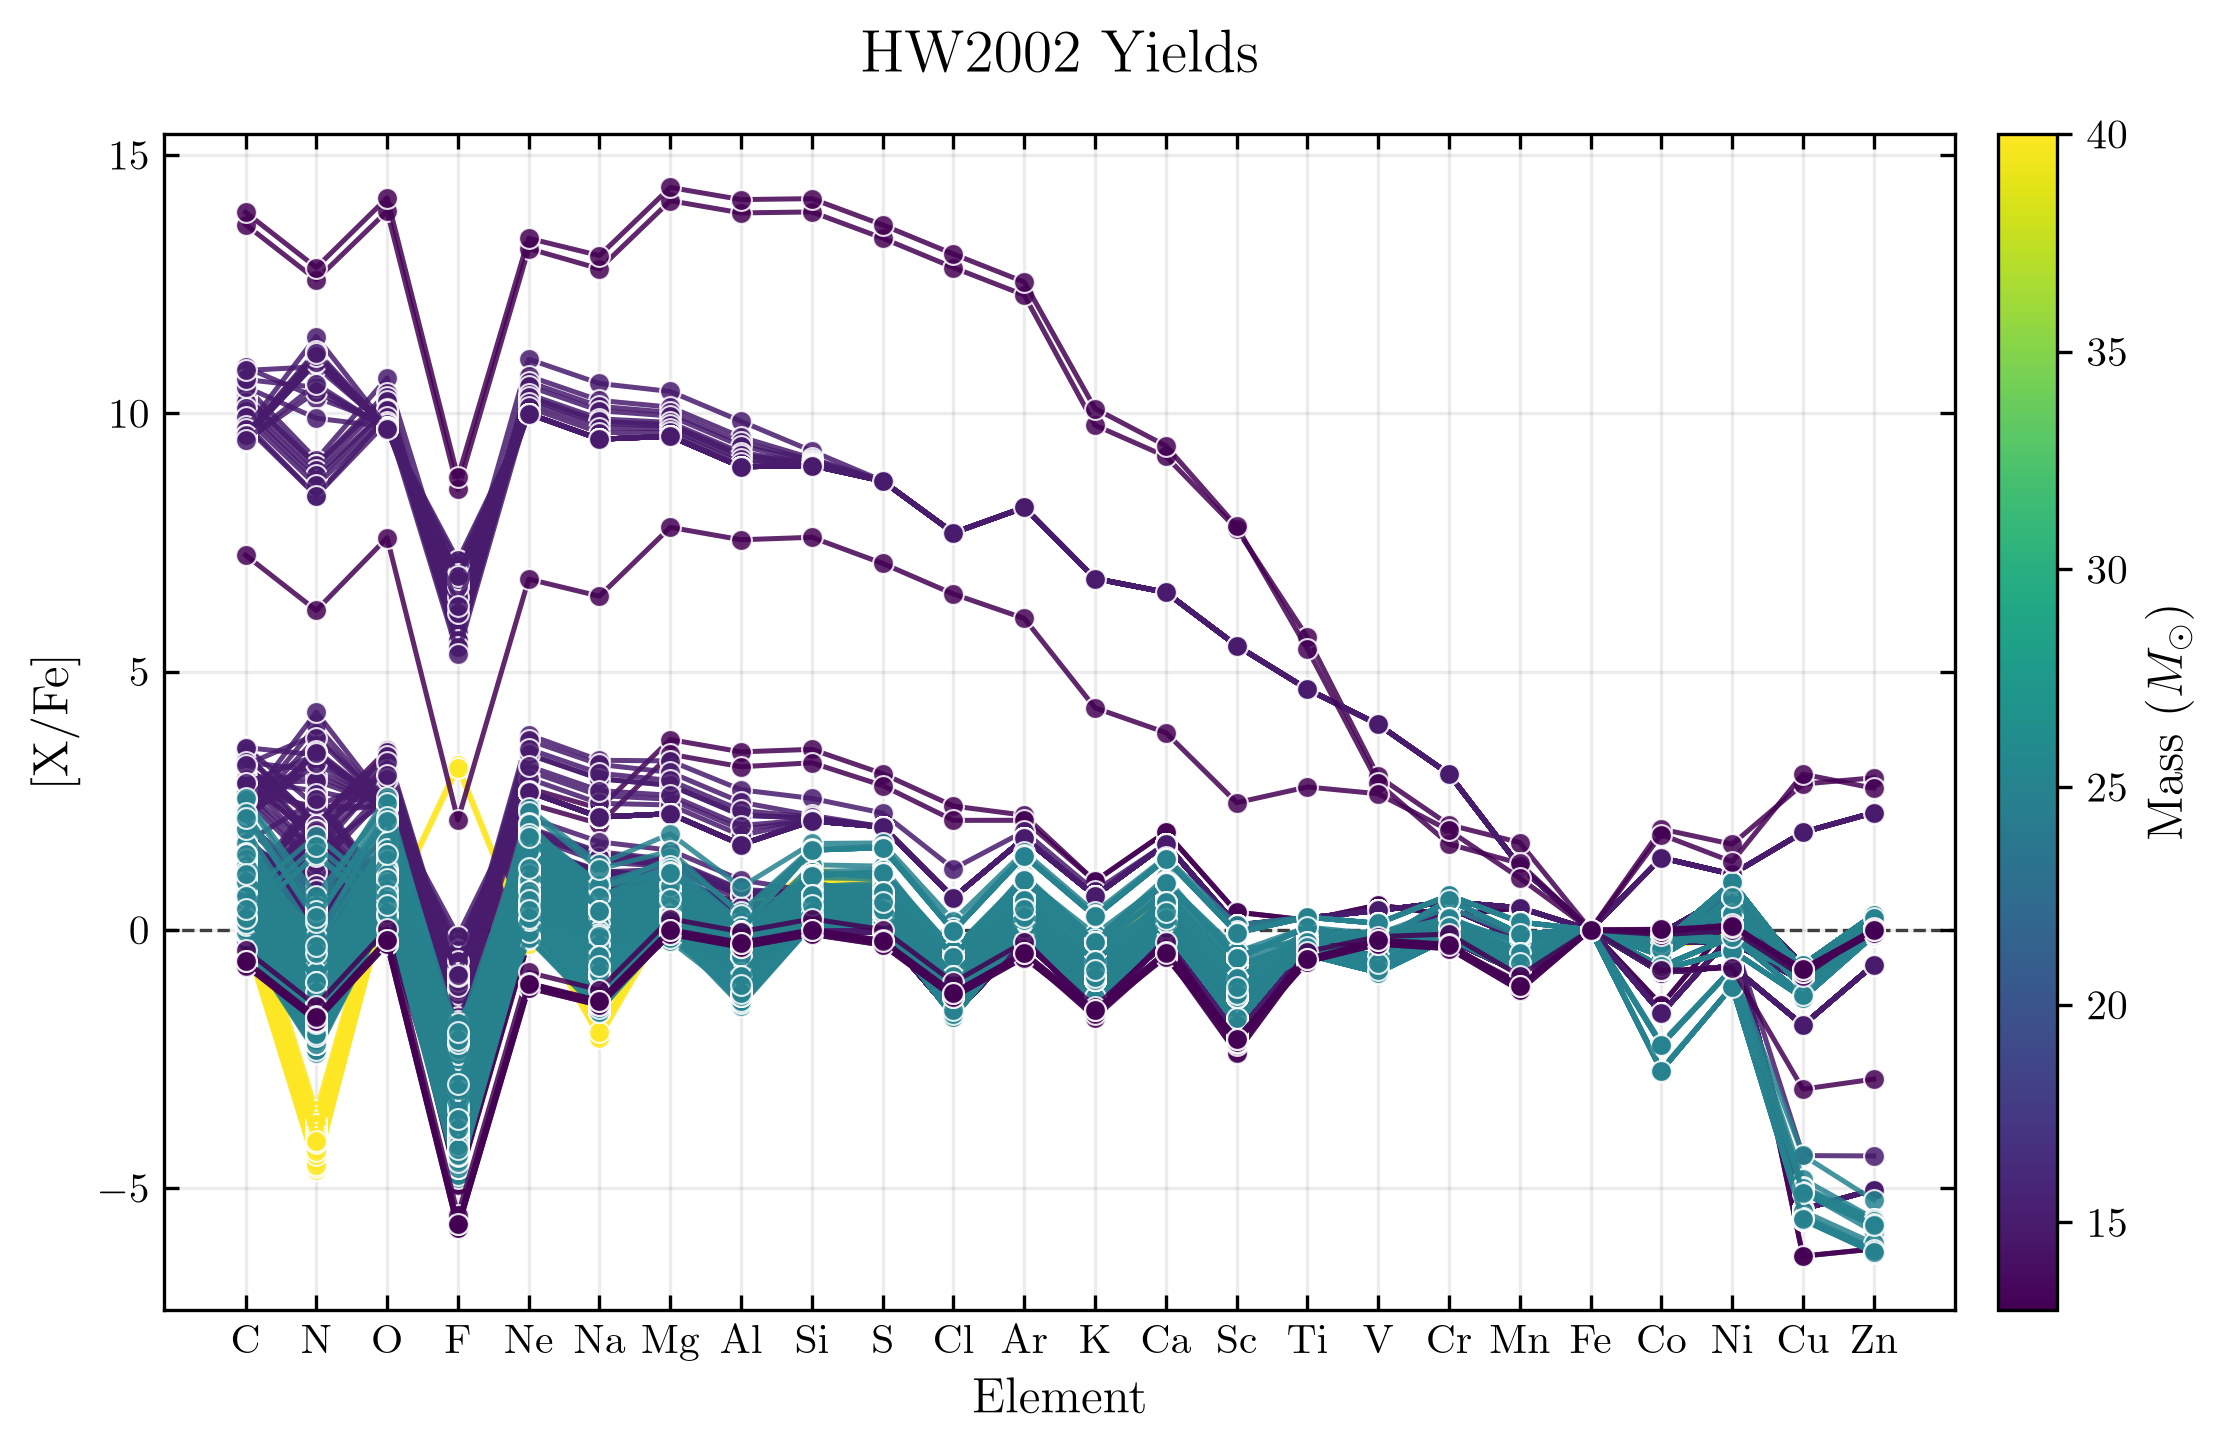

In [13]:
plot_yields(ishigaki18_selected_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

In [14]:
# plot_yields(ishigaki_yields, title="Ishigaki 2018 Yields", combine_elements=True, filter_elements=filter_elements)